# 06 · Campaign performance, pilot economics, campaign × segment
**Formulas (pilot C6 only — the only campaign with cost information):**
cost = contacts × 3 MU · campaign revenue = responses × 11 MU · profit = revenue − cost · ROI = profit / cost ·
break-even response rate = 3 / 11 = 27.3 %. The 11 MU is *campaign revenue per response* as defined by the case — not profit margin.
ROAS/CAC cannot be computed (no acquisition spend); C1–C5 have no cost data, so only acceptance is compared.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4g}")
from src import pipeline as P
from src.config import *

[19:41:09] campaigns + channels


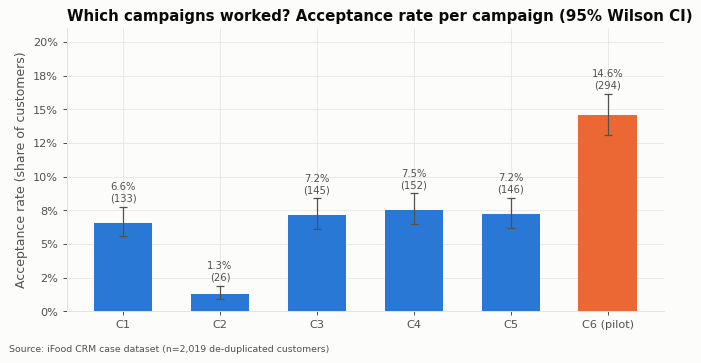

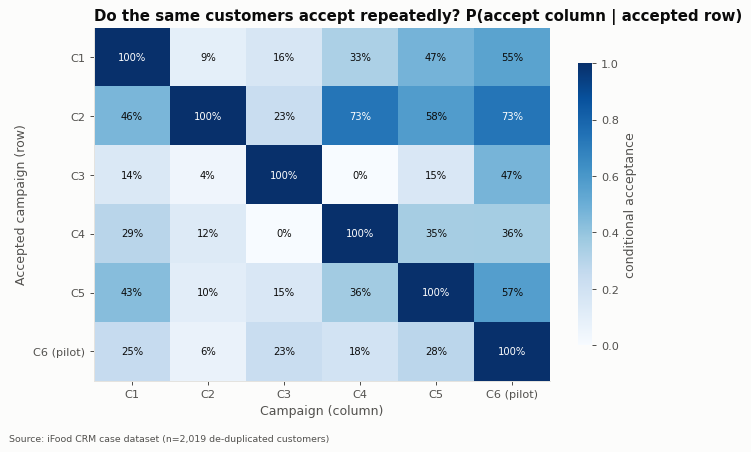

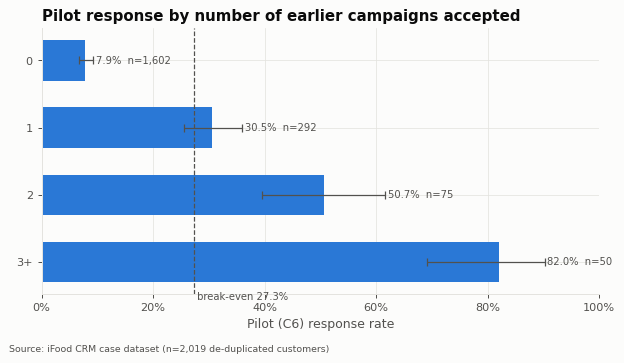

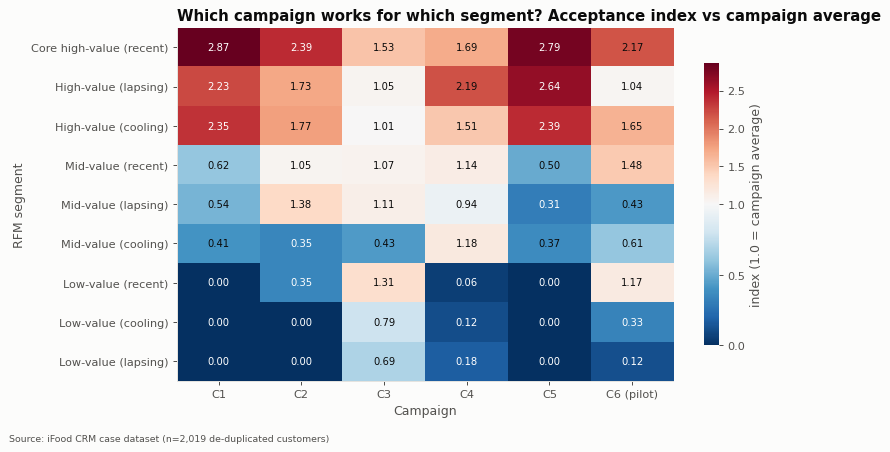

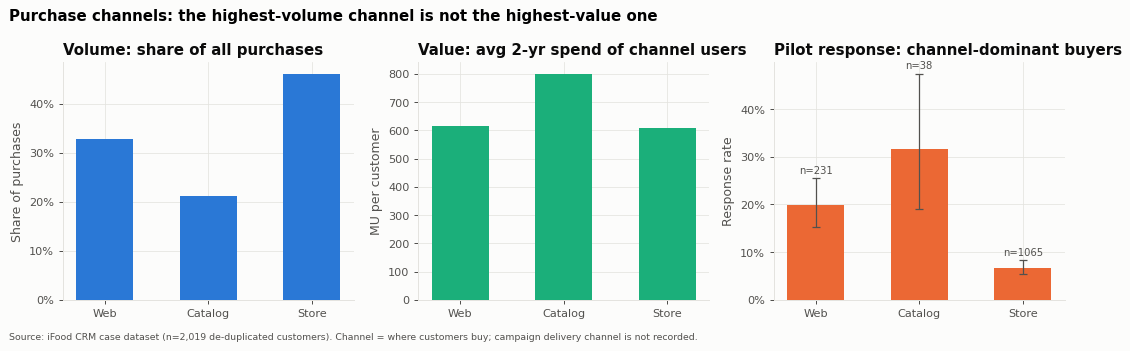

,scope,contacts,responses,response_rate,rr_ci_low,rr_ci_high,cost,revenue,profit,roi,profit_per_contact
0,pilot_all_customers,"2,019",294,0.1456,0.1309,0.1617,"6,057","3,234","-2,823",-0.4661,-1.398


In [2]:
ctx = P.prepare('stage_campaigns')
ctx = P.stage_campaigns(ctx)
ctx['econ']

> **Finding:** The pilot contacted all 2,019 customers: 294 responses (14.6 %), cost 6,057 MU, revenue 3,234 MU, profit −2,823 MU (ROI −47 %). (On the raw file with duplicates: −3,046 MU, matching the case statement.)
>
> **Business implication:** Mass contact destroys value when the response rate is below 27.3 %.
>
> **Recommended action:** Contact only customers whose expected response exceeds break-even (notebooks 09–10).
>
> **Evidence:** Actual pilot outcomes × dataset cost/revenue constants.
>
> **Assumption:** The 3 / 11 MU economics apply to the next campaign.
>
> **Limitation:** Profit excludes any long-term value of a response and any cannibalisation.

In [3]:
ctx['econ_seg']

,rfm_segment,contacts,responses,response_rate,rr_ci_low,rr_ci_high,cost,revenue,profit,roi,profit_per_contact
0,Core high-value (recent),228,72,0.3158,0.2589,0.3788,684,792,108,0.1579,0.4737
1,High-value (cooling),220,53,0.2409,0.1892,0.3016,660,583,-77,-0.1167,-0.35
2,Mid-value (recent),222,48,0.2162,0.1671,0.2749,666,528,-138,-0.2072,-0.6216
3,Low-value (recent),223,38,0.1704,0.1267,0.2252,669,418,-251,-0.3752,-1.126
4,High-value (lapsing),225,34,0.1511,0.1102,0.2037,675,374,-301,-0.4459,-1.338
5,Mid-value (cooling),225,20,0.08889,0.05828,0.1333,675,220,-455,-0.6741,-2.022
6,Mid-value (lapsing),226,14,0.06195,0.03726,0.1013,678,154,-524,-0.7729,-2.319
7,Low-value (cooling),228,11,0.04825,0.02715,0.08431,684,121,-563,-0.8231,-2.469
8,Low-value (lapsing),222,4,0.01802,0.007029,0.0454,666,44,-622,-0.9339,-2.802


## Which campaign works for which segment?

In [4]:
ctx['cxs_index'].round(2)

,C1,C2,C3,C4,C5,C6 (pilot)
rfm_segment,,,,,,
Core high-value (recent),2.87,2.39,1.53,1.69,2.79,2.17
High-value (cooling),2.35,1.77,1.01,1.51,2.39,1.65
High-value (lapsing),2.23,1.73,1.05,2.19,2.64,1.04
Low-value (cooling),0,0,0.79,0.12,0,0.33
Low-value (lapsing),0,0,0.69,0.18,0,0.12
Low-value (recent),0,0.35,1.31,0.06,0,1.17
Mid-value (cooling),0.41,0.35,0.43,1.18,0.37,0.61
Mid-value (lapsing),0.54,1.38,1.11,0.94,0.31,0.43
Mid-value (recent),0.62,1.05,1.07,1.14,0.5,1.48


In [5]:
ctx['cxs_tests']

,campaign,chi2,dof,p_value,cramers_v,p_bh
0,C1,166.6,8,6.687e-32,0.2872,2.006e-31
1,C2,17.71,8,0.02352,0.09365,0.02823
2,C3,14.89,8,0.06125,0.08589,0.06125
3,C4,82.88,8,1.284e-14,0.2026,1.927e-14
4,C5,209.6,8,5.934e-41,0.3222,3.56e-40
5,C6 (pilot),144.1,8,3.261e-27,0.2672,6.522e-27


In [6]:
ctx['cxs_long'].query('acceptors >= 10').sort_values('index_vs_overall', ascending=False).head(12)

,segment,campaign,n,acceptors,rate,ci_low,ci_high,overall_rate,index_vs_overall
0,Core high-value (recent),C1,228,43,0.1886,0.1431,0.2444,0.06587,2.863
4,Core high-value (recent),C5,228,46,0.2018,0.1548,0.2586,0.07231,2.79
16,High-value (lapsing),C5,225,43,0.1911,0.1451,0.2475,0.07231,2.643
10,High-value (cooling),C5,220,38,0.1727,0.1285,0.2282,0.07231,2.389
6,High-value (cooling),C1,220,34,0.1545,0.1128,0.2082,0.06587,2.346
12,High-value (lapsing),C1,225,33,0.1467,0.1064,0.1988,0.06587,2.226
15,High-value (lapsing),C4,225,37,0.1644,0.1217,0.2184,0.07528,2.184
5,Core high-value (recent),C6 (pilot),228,72,0.3158,0.2589,0.3788,0.1456,2.169
3,Core high-value (recent),C4,228,29,0.1272,0.09004,0.1767,0.07528,1.689
11,High-value (cooling),C6 (pilot),220,53,0.2409,0.1892,0.3016,0.1456,1.654


> **Finding:** C1, C2, C4 and C5 over-index 2–3× in the three high-value segments and barely reach low-value customers (C5: 0 acceptors among 674 low-value customers). C3 is different: it is the only campaign with no significant segment pattern (BH-adjusted p = 0.06) and it reaches low-value recent customers (index 1.31).
>
> **Business implication:** Campaign content determines who responds; most offers appeal to affluent, high-spend customers.
>
> **Recommended action:** Match the next offer to the audience: premium-style offers to the high-value tiers; a C3-style offer is the only observed route to low-value customers.
>
> **Evidence:** Campaign × segment acceptance matrix, χ² per campaign with BH correction.
>
> **Assumption:** All customers were eligible for every campaign.
>
> **Limitation:** Exposure to C1–C5 is not recorded (acceptance ≠ response rate among the exposed) and offer contents are undocumented. Campaign fatigue cannot be analysed: there are no exposure histories or campaign dates.

## Funnel
The data observe only two stages for the pilot: contacted (2,019) → accepted (294). Engagement (opens, clicks, visits after the campaign) is not recorded, so no further funnel stages are built.

In [7]:
ctx['dominant_channel_response']

,group,responders,n,rate,ci_low,ci_high
0,Catalog,12,38,0.3158,0.1908,0.4746
1,Mixed,165,679,0.243,0.2122,0.2767
2,No purchases,0,6,0,2.776e-17,0.3903
3,Store,71,1065,0.06667,0.05319,0.08326
4,Web,46,231,0.1991,0.1527,0.2554
